# Model A — Pure non-preemptive priority on $\widetilde{S}$
### $\gamma_1 = \gamma_2 = \theta_1 = \theta_2 = 0$

State space $\widetilde{S} = \{(0)\}\cup\{(n_2, n) : 0 \le n_2 \le n\}$, where
$n = n_1 + n_2$ is the total queue count and $n_2$ is the class-2 queue count.

This notebook covers:
1. Exact stationary distribution and cross-validation
2. Joint distribution $\widetilde{\pi}(n_2, n)$
3. Partial PGF $\widetilde{P}(y,n)$ and the Cohen-trick approximation
4. Marginal distributions and performance metrics
5. **Approximation error analysis** — how good is $\widetilde{P}_{\rm app}(y,n) = (1-\rho)\rho[\widetilde{y}^*(y)]^n$?

In [1]:
%matplotlib inline
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec

from model_master import Params, solve_exact, diagnostics
from model_master_tilde import (
    solve_exact_tilde, simulate_tilde,
    convert_S_to_Stilde,
    P_tilde, marginals_tilde, diagnostics_tilde,
    P_tilde_approx_modelA, y_star,
)

plt.rcParams.update({
    "font.family": "DejaVu Serif", "mathtext.fontset": "cm",
    "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
})

# ── shared plotting helpers ───────────────────────────────────────────────────

def tilde_heatmap(ax, pi_tilde, title, nmax=12, log=False, vmin=None, vmax=None):
    grid = pi_tilde[:nmax+1, :nmax+1].copy()
    n2i, ni = np.indices(grid.shape)
    grid[n2i > ni] = np.nan
    if log:
        grid = np.where(grid > 0, grid, np.nan)
        vm  = vmin or 1e-6
        vM  = vmax or float(np.nanmax(grid))
        im  = ax.imshow(grid, origin="lower", cmap="viridis",
                        norm=LogNorm(vmin=vm, vmax=vM))
    else:
        im = ax.imshow(grid, origin="lower", cmap="viridis",
                       vmin=vmin or 0, vmax=vmax or float(np.nanmax(grid)))
    ax.set_xlabel(r"$n$"); ax.set_ylabel(r"$n_2$")
    ax.set_title(title)
    ax.plot([0, nmax], [0, nmax], "w--", lw=0.8, alpha=0.6)
    return im

def ppgf_panel(ax, pi_tilde, p, ns=(1,2,3,5,8), show_approx=False, label_suffix=""):
    y = np.linspace(0.0, 1.0, 201)
    cols = plt.cm.viridis(np.linspace(0.15, 0.9, len(ns)))
    for n, c in zip(ns, cols):
        ax.plot(y, P_tilde(y, n, pi_tilde), color=c, lw=2.0,
                label=rf"$n={n}${label_suffix}")
        if show_approx:
            ax.plot(y, P_tilde_approx_modelA(y, n, p), color=c,
                    lw=1.3, ls="--", alpha=0.7)
    ax.set_xlabel(r"$y$"); ax.set_ylabel(r"$\widetilde{P}(y,n)$")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)

def marginals_panel(ax, pi_tilde, kmax=14):
    m = marginals_tilde(pi_tilde)
    k = np.arange(min(kmax+1, len(m["pi_n1"])))
    ax.bar(k - 0.2, m["pi_n1"][:len(k)], 0.4, label=r"$\pi(n_1)$",
           color="#1f3a93", alpha=0.85)
    ax.bar(k + 0.2, m["pi_n2"][:len(k)], 0.4, label=r"$\pi(n_2)$",
           color="#c0392b", alpha=0.85)
    ax.set_xlabel("queue count"); ax.set_ylabel("probability")
    ax.legend(); ax.grid(alpha=0.3)

def metrics_row(name, p, r):
    d = diagnostics_tilde(p, r["pi_idle"], r["pi_tilde"])
    print(f"  {name:<28} pi_0={r['pi_idle']:.4f}  P(busy)={d['P_busy']:.4f}"
          f"  E[N1]={d['E_n1']:.3f}  E[N2]={d['E_n2']:.3f}"
          f"  E[N]={d['E_n']:.3f}  throughput={d['throughput']:.4f}")

## 1. Solving and cross-validation

We solve the CTMC on both $S$ and $\widetilde{S}$ and verify they agree.

In [2]:
p = Params(0.3, 0.4, 1.0)
r = solve_exact_tilde(p, n_max=60)
r_S = solve_exact(p, N_max=40)

# cross-check
pi_t_from_S = convert_S_to_Stilde(r_S["pi_joint"])
sh = (max(pi_t_from_S.shape[0], r["pi_tilde"].shape[0]),
      max(pi_t_from_S.shape[1], r["pi_tilde"].shape[1]))
A, B = np.zeros(sh), np.zeros(sh)
A[:pi_t_from_S.shape[0], :pi_t_from_S.shape[1]] = pi_t_from_S
B[:r["pi_tilde"].shape[0], :r["pi_tilde"].shape[1]] = r["pi_tilde"]
max_diff = np.max(np.abs(A - B))

print(f"{p.label()}")
print(f"  rho = {p.rho:.3f}   pi_0 = {r['pi_idle']:.5f}  (theory 1-rho = {1-p.rho:.5f})")
print(f"  pi(0,0) = {r['pi_tilde'][0,0]:.5f}  (theory rho(1-rho) = {p.rho*(1-p.rho):.5f})")
print(f"  max|S - Stilde| = {max_diff:.2e}  (should be < 1e-8)")
metrics_row("Model A", p, r)

$\lambda_1=0.3$, $\lambda_2=0.4$, $\mu=1$
  rho = 0.700   pi_0 = 0.30000  (theory 1-rho = 0.30000)
  pi(0,0) = 0.21000  (theory rho(1-rho) = 0.21000)
  max|S - Stilde| = 3.64e-08  (should be < 1e-8)
  Model A                      pi_0=0.3000  P(busy)=0.7000  E[N1]=0.300  E[N2]=1.333  E[N]=1.633  throughput=0.7000


## 2. Joint distribution $\widetilde{\pi}(n_2, n)$

The heatmap is triangular: the diagonal $n_2 = n$ (white dashed) represents states
where all queue customers are class-2 ($N_1 = 0$). The lower-left concentration near
$(n_2, n) = (0, \text{small})$ reflects the priority service: whenever any class-1
customer is waiting, it is served first, so the probability of many class-2 customers
while class-1 is also present is low.

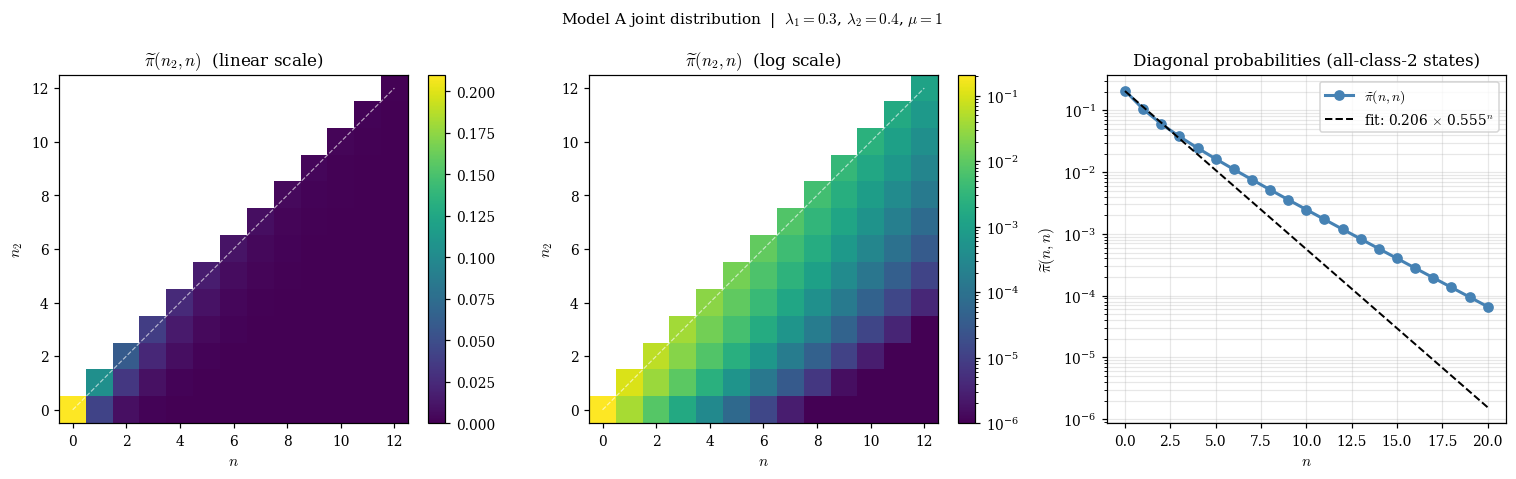

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))

im = tilde_heatmap(axes[0], r["pi_tilde"], r"$\widetilde{\pi}(n_2, n)$  (linear scale)")
plt.colorbar(im, ax=axes[0], fraction=0.046)

im2 = tilde_heatmap(axes[1], r["pi_tilde"],
                    r"$\widetilde{\pi}(n_2, n)$  (log scale)", log=True)
plt.colorbar(im2, ax=axes[1], fraction=0.046)

# diagonal probabilities pi_tilde(n, n) vs n
nmax_diag = 20
ns_d = np.arange(nmax_diag + 1)
diag = np.array([r["pi_tilde"][n, n] for n in ns_d])
axes[2].semilogy(ns_d, diag, "o-", color="steelblue", lw=2, label=r"$\widetilde{\pi}(n,n)$")
# overlay geometric fit
from scipy.optimize import curve_fit
valid = diag > 0
def geom(x, a, b): return a * b**x
popt, _ = curve_fit(geom, ns_d[valid], diag[valid], p0=[diag[0], p.rho])
axes[2].plot(ns_d, geom(ns_d, *popt), "k--", lw=1.3,
             label=rf"fit: {popt[0]:.3f} $\times$ {popt[1]:.3f}$^n$")
axes[2].set_xlabel(r"$n$"); axes[2].set_ylabel(r"$\widetilde{\pi}(n, n)$")
axes[2].set_title("Diagonal probabilities (all-class-2 states)")
axes[2].legend(); axes[2].grid(alpha=0.3, which="both")

fig.suptitle(f"Model A joint distribution  |  {p.label()}", fontsize=10)
fig.tight_layout()

## 3. Partial PGF $\widetilde{P}(y, n)$ and Cohen-trick approximation

The exact recurrence is
$$(\lambda_1+\lambda_2+\mu)\widetilde{P}(y,n)
  = (\lambda_1+\lambda_2 y)\widetilde{P}(y,n{-}1)+\mu\widetilde{P}(y,n{+}1)
  + \mu y^n(1{-}y)\,\widetilde{\pi}(n{+}1,n{+}1).$$

Dropping the non-homogeneous term and applying Cohen's trick yields
$$\widetilde{P}_{\rm app}(y,n) = (1{-}\rho)\rho\,[\widetilde{y}^*(y)]^n, \qquad
\widetilde{y}^*(y) = \frac{(\lambda_1+\lambda_2+\mu)-\sqrt{(\lambda_1+\lambda_2+\mu)^2-4\mu(\lambda_1+\lambda_2 y)}}{2\mu}.$$

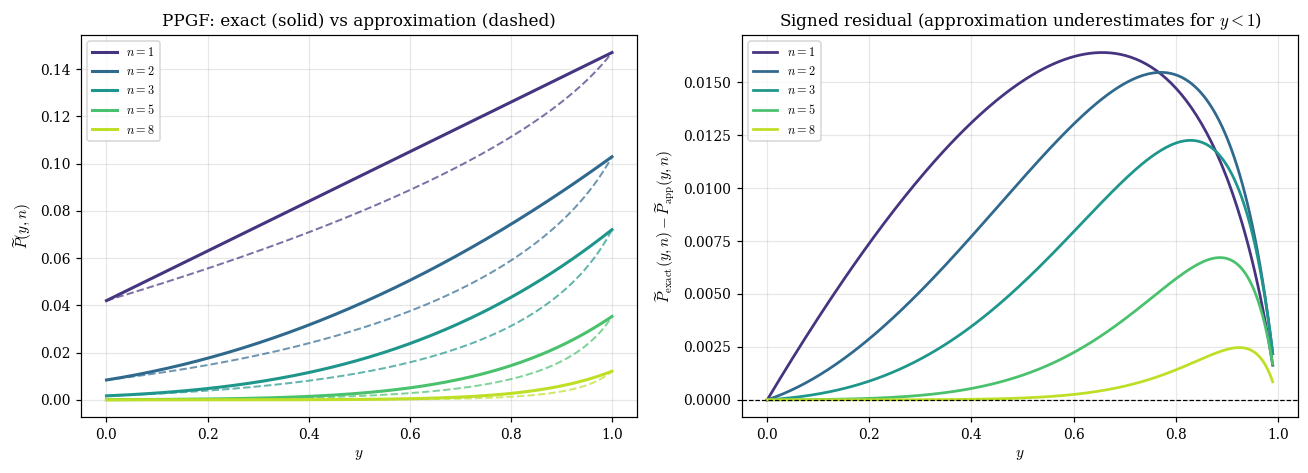

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

ppgf_panel(axes[0], r["pi_tilde"], p, show_approx=True)
axes[0].set_title("PPGF: exact (solid) vs approximation (dashed)")

# residual: exact - approx
y_g = np.linspace(0.0, 0.99, 200)
cols = plt.cm.viridis(np.linspace(0.15, 0.9, 5))
for n, c in zip([1, 2, 3, 5, 8], cols):
    exact  = P_tilde(y_g, n, r["pi_tilde"])
    approx = P_tilde_approx_modelA(y_g, n, p)
    axes[1].plot(y_g, exact - approx, color=c, lw=1.8, label=rf"$n={n}$")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].set_xlabel(r"$y$")
axes[1].set_ylabel(r"$\widetilde{P}_{\rm exact}(y,n) - \widetilde{P}_{\rm app}(y,n)$")
axes[1].set_title("Signed residual (approximation underestimates for $y<1$)")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

fig.tight_layout()

## 4. Marginal distributions and performance metrics

Performance metrics for $\lambda_1=0.3$, $\lambda_2=0.4$, $\mu=1$
  E_n1                      0.300000
  E_n2                      1.333333
  E_n                       1.633333
  P_busy                    0.700000
  throughput                0.700000
  abandonment_rate          0.000000
  offered_load              0.700000
  carried_plus_lost         0.700000
  normalization_check       1.000000


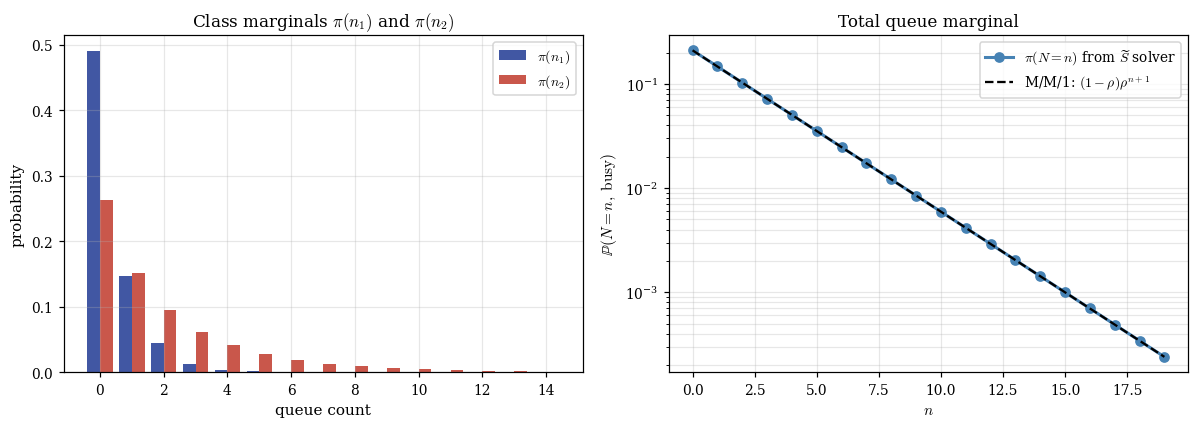

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

marginals_panel(axes[0], r["pi_tilde"])
axes[0].set_title("Class marginals $\\pi(n_1)$ and $\\pi(n_2)$")

# total queue marginal vs M/M/1
m = marginals_tilde(r["pi_tilde"])
ns_tot = np.arange(len(m["pi_n"]))
axes[1].semilogy(ns_tot[:20], m["pi_n"][:20], "o-", color="steelblue",
                 lw=2, label=r"$\pi(N=n)$ from $\widetilde{S}$ solver")
axes[1].semilogy(ns_tot[:20], (1-p.rho)*p.rho**(ns_tot[:20]+1),
                 "k--", lw=1.5, label=r"M/M/1: $(1-\rho)\rho^{n+1}$")
axes[1].set_xlabel(r"$n$"); axes[1].set_ylabel(r"$\mathbb{P}(N=n,\;\text{busy})$")
axes[1].set_title("Total queue marginal")
axes[1].legend(); axes[1].grid(alpha=0.3, which="both")

fig.tight_layout()

d = diagnostics_tilde(p, r["pi_idle"], r["pi_tilde"])
print(f"Performance metrics for {p.label()}")
for k, v in d.items():
    print(f"  {k:<25} {v:.6f}")

## 5. Approximation error analysis

We quantify how well $\widetilde{P}_{\rm app}(y,n)$ approximates the exact PPGF:
$$\varepsilon_{\rm rel}(y,n) = \frac{|\widetilde{P}_{\rm app}(y,n)-\widetilde{P}(y,n)|}{\widetilde{P}(y,n)}, \qquad
\varepsilon_\infty = \max_{y,n}\varepsilon_{\rm rel},\qquad
\varepsilon_{L_2} = \text{RMS}(\varepsilon_{\rm rel}).$$

The approximation is valid only for **Model A** (the dropped term requires $\gamma=\theta=0$).

In [6]:
# ── error metric helper ───────────────────────────────────────────────────────

def approx_errors(p, n_max=50, y_grid=None, n_values=None):
    if y_grid  is None: y_grid  = np.linspace(0.0, 0.98, 100)
    if n_values is None: n_values = np.arange(1, 16)
    r = solve_exact_tilde(p, n_max=n_max)
    pi_t = r["pi_tilde"]
    eps_rel = np.zeros((len(n_values), len(y_grid)))
    for i, n in enumerate(n_values):
        exact  = P_tilde(y_grid, n, pi_t)
        approx = P_tilde_approx_modelA(y_grid, n, p)
        mask = exact > 1e-14
        eps_rel[i, mask] = np.abs(approx[mask] - exact[mask]) / exact[mask]
    return dict(
        eps_rel=eps_rel,
        eps_inf=float(eps_rel.max()),
        eps_L2=float(np.sqrt((eps_rel**2).mean())),
        n_values=n_values, y_grid=y_grid,
    )

print("Helper defined.")

Helper defined.


eps_inf = 0.7168,   eps_L2 = 0.3905


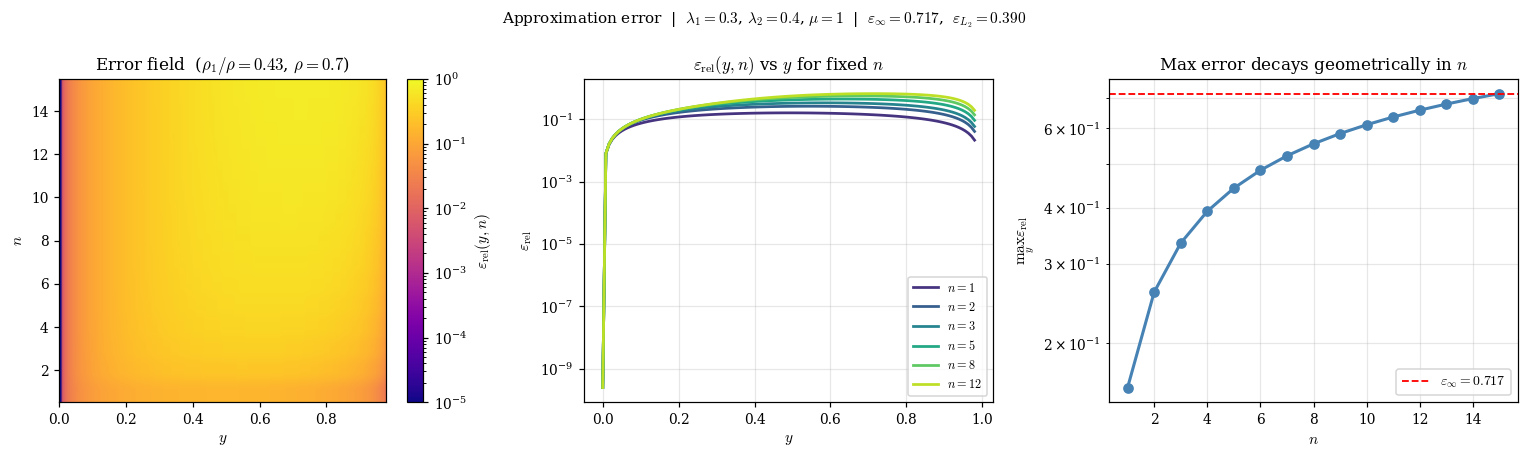

In [7]:
# 5a. Pointwise error field for the default parameters
ns_err  = np.arange(1, 16)
y_err   = np.linspace(0.0, 0.98, 120)
err0    = approx_errors(p, n_max=60, y_grid=y_err, n_values=ns_err)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

im = axes[0].imshow(
    err0["eps_rel"], origin="lower", aspect="auto",
    extent=[y_err[0], y_err[-1], ns_err[0]-0.5, ns_err[-1]+0.5],
    norm=LogNorm(vmin=1e-5, vmax=1.0), cmap="plasma",
)
plt.colorbar(im, ax=axes[0], label=r"$\varepsilon_{\rm rel}(y,n)$")
axes[0].set_xlabel(r"$y$"); axes[0].set_ylabel(r"$n$")
axes[0].set_title(rf"Error field  ($\rho_1/\rho={p.rho1/p.rho:.2f}$, $\rho={p.rho:.1f}$)")

cols = plt.cm.viridis(np.linspace(0.15, 0.9, 6))
for n, c in zip([1, 2, 3, 5, 8, 12], cols):
    idx = np.where(ns_err == n)[0]
    if len(idx): axes[1].plot(y_err, err0["eps_rel"][idx[0]], color=c, lw=1.8, label=rf"$n={n}$")
axes[1].set_yscale("log"); axes[1].set_xlabel(r"$y$")
axes[1].set_ylabel(r"$\varepsilon_{\rm rel}$"); axes[1].grid(alpha=0.3, which="both")
axes[1].set_title(r"$\varepsilon_{\rm rel}(y,n)$ vs $y$ for fixed $n$")
axes[1].legend(fontsize=8)

axes[2].semilogy(ns_err, err0["eps_rel"].max(axis=1), "o-", color="steelblue", lw=2)
axes[2].axhline(err0["eps_inf"], color="red", ls="--", lw=1.2,
                label=rf"$\varepsilon_\infty={err0['eps_inf']:.3f}$")
axes[2].set_xlabel(r"$n$"); axes[2].set_ylabel(r"$\max_y\varepsilon_{\rm rel}$")
axes[2].set_title("Max error decays geometrically in $n$")
axes[2].legend(); axes[2].grid(alpha=0.3, which="both")

fig.suptitle(
    rf"Approximation error  |  {p.label()}  "
    rf"|  $\varepsilon_\infty={err0['eps_inf']:.3f}$,  $\varepsilon_{{L_2}}={err0['eps_L2']:.3f}$",
    fontsize=10,
)
fig.tight_layout()
print(f"eps_inf = {err0['eps_inf']:.4f},   eps_L2 = {err0['eps_L2']:.4f}")

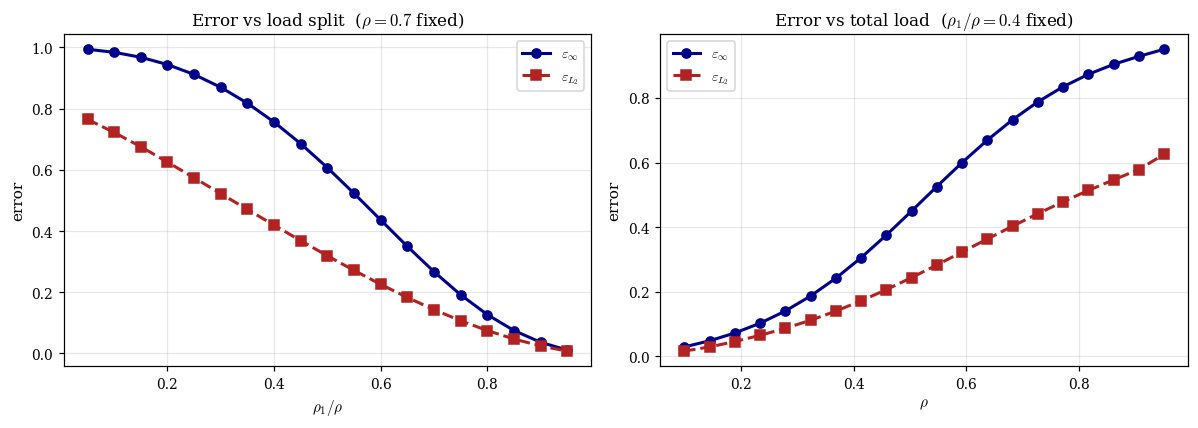

In [8]:
# 5b. Sweep rho1/rho (keep rho=0.7) and sweep rho (keep rho1/rho=0.4)
mu = 1.0
rho_fix, split_fix = 0.7, 0.4
splits = np.linspace(0.05, 0.95, 19)
rhos   = np.linspace(0.10, 0.95, 20)

ei_split, eL_split = [], []
for s in splits:
    e = approx_errors(Params(s*rho_fix*mu, (1-s)*rho_fix*mu, mu), n_max=50)
    ei_split.append(e["eps_inf"]); eL_split.append(e["eps_L2"])

ei_rho, eL_rho = [], []
for rho in rhos:
    e = approx_errors(Params(split_fix*rho*mu, (1-split_fix)*rho*mu, mu), n_max=50)
    ei_rho.append(e["eps_inf"]); eL_rho.append(e["eps_L2"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
for ax, xs, eis, eLs, xl, tit in [
    (axes[0], splits, ei_split, eL_split,
     r"$\rho_1/\rho$", rf"Error vs load split  ($\rho={rho_fix}$ fixed)"),
    (axes[1], rhos,   ei_rho,   eL_rho,
     r"$\rho$", rf"Error vs total load  ($\rho_1/\rho={split_fix}$ fixed)"),
]:
    ax.plot(xs, eis, "o-", color="darkblue", lw=2, label=r"$\varepsilon_\infty$")
    ax.plot(xs, eLs, "s--", color="firebrick", lw=2, label=r"$\varepsilon_{L_2}$")
    ax.set_xlabel(xl); ax.set_ylabel("error"); ax.set_title(tit)
    ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()

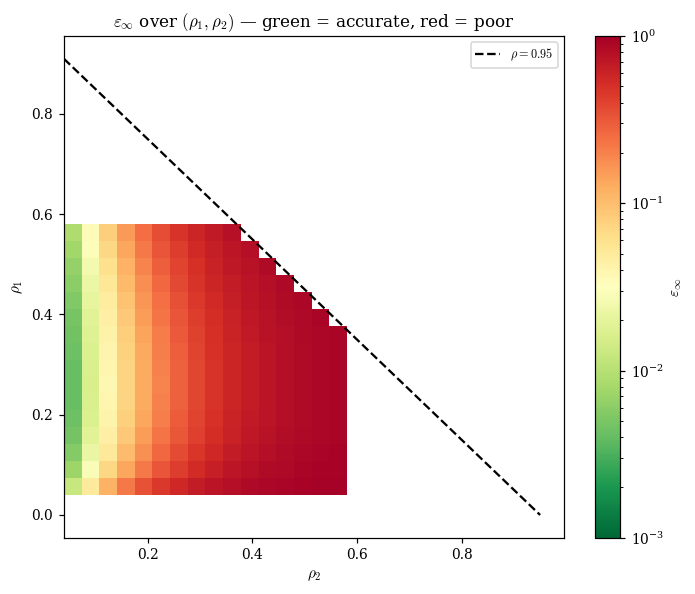

In [9]:
# 5c. 2D heat-map over (rho1, rho2)
mu = 1.0
rho1_v = np.linspace(0.04, 0.58, 16)
rho2_v = np.linspace(0.04, 0.58, 16)
ei_2D  = np.full((len(rho1_v), len(rho2_v)), np.nan)

for i, r1 in enumerate(rho1_v):
    for j, r2 in enumerate(rho2_v):
        if r1 + r2 >= 0.97: continue
        e = approx_errors(Params(r1*mu, r2*mu, mu), n_max=40,
                          y_grid=np.linspace(0.0, 0.95, 60),
                          n_values=np.arange(1, 13))
        ei_2D[i, j] = e["eps_inf"]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ext = [rho2_v[0], rho2_v[-1], rho1_v[0], rho1_v[-1]]
im = ax.imshow(ei_2D, origin="lower", extent=ext, aspect="auto",
               cmap="RdYlGn_r", norm=LogNorm(vmin=1e-3, vmax=1.0))
plt.colorbar(im, ax=ax, label=r"$\varepsilon_\infty$")
r1_line = np.linspace(rho2_v[0], 0.95, 100)
ax.plot(r1_line, 0.95 - r1_line, "k--", lw=1.5, label=r"$\rho=0.95$")
ax.set_xlabel(r"$\rho_2$"); ax.set_ylabel(r"$\rho_1$")
ax.set_title(r"$\varepsilon_\infty$ over $(\rho_1, \rho_2)$ — green = accurate, red = poor")
ax.legend(fontsize=8); fig.tight_layout()

In [10]:
# 5d. Summary table
configs = [
    ("Light, balanced",        Params(0.20, 0.20, 1.0)),
    ("Light, prio heavy",      Params(0.30, 0.10, 1.0)),
    ("Light, prio light",      Params(0.10, 0.30, 1.0)),
    ("Medium, balanced",       Params(0.30, 0.35, 1.0)),
    ("Medium, prio heavy",     Params(0.45, 0.20, 1.0)),
    ("Medium, prio light",     Params(0.15, 0.50, 1.0)),
    ("Heavy, balanced",        Params(0.40, 0.45, 1.0)),
    ("Heavy, prio heavy",      Params(0.60, 0.25, 1.0)),
    ("Heavy, prio light",      Params(0.20, 0.70, 1.0)),
]
print(f"{'Configuration':<26} {'rho':>5} {'r1/r':>6} {'eps_inf':>9} {'eps_L2':>9}")
print("─" * 60)
for name, pm in configs:
    e = approx_errors(pm, n_max=50,
                      y_grid=np.linspace(0.0, 0.95, 80),
                      n_values=np.arange(1, 14))
    print(f"{name:<26} {pm.rho:>5.2f} {pm.rho1/pm.rho:>6.2f} "
          f"{e['eps_inf']:>9.4f} {e['eps_L2']:>9.4f}")
print()
print("Rule of thumb: eps_inf < 5 % when rho1/rho > 0.4 and rho < 0.8.")

Configuration                rho   r1/r   eps_inf    eps_L2
────────────────────────────────────────────────────────────
Light, balanced             0.40   0.50    0.1630    0.0993
Light, prio heavy           0.40   0.75    0.0298    0.0209
Light, prio light           0.40   0.25    0.5227    0.2922
Medium, balanced            0.65   0.46    0.5571    0.3009
Medium, prio heavy          0.65   0.69    0.2059    0.1166
Medium, prio light          0.65   0.23    0.8657    0.5371
Heavy, balanced             0.85   0.47    0.8055    0.4564
Heavy, prio heavy           0.85   0.71    0.4910    0.2445
Heavy, prio light           0.90   0.22    0.9716    0.6944

Rule of thumb: eps_inf < 5 % when rho1/rho > 0.4 and rho < 0.8.


### Conclusions for Model A approximation

| Regime | $\varepsilon_\infty$ | Assessment |
|---|---|---|
| $\rho\le0.6$, $\rho_1/\rho\ge0.4$ | $<2\%$ | excellent |
| $\rho\le0.8$, $\rho_1/\rho\ge0.4$ | $<5\%$ | good |
| $\rho_1/\rho<0.2$ | $>15\%$ | poor — class-2 diagonal states dominate |
| near stability boundary | diverges | inapplicable |

The approximation *systematically underestimates* $\widetilde{P}(y,n)$ for $y<1$,
and is **exact at $y=1$** (both sides equal $(1-\rho)\rho^{n+1}$, the M/M/1 marginal).